# Aplicación de XGBoost

En este Notebook se muestra el desarrollo de la aplicación del modelo XGBoost para la predicción de la clasificación del desempeño de los estudiantes que presentaron la prueba ICFES saber 11.

### 1. Importación de librerías base

In [2]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import os
import time
import warnings
import json
from collections import Counter

# ── Datos ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ── Scikit-learn ──────────────────────────────────────────────────────────────
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OrdinalEncoder, StandardScaler, LabelEncoder, OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier
import xgboost as xgb

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# ── API Socrata ───────────────────────────────────────────────────────────────
from sodapy import Socrata

# ── Configuraciones globales ──────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

print('✅ Entorno configurado.')
print(f'   NumPy:       {np.__version__}')
print(f'   Pandas:      {pd.__version__}')
print(f'   XGBoost:     {xgb.__version__}')
print(f'   TensorFlow:  {tf.__version__}')
print(f'   Scikit-learn:  {sklearn.__version__}')


✅ Entorno configurado.
   NumPy:       2.3.2
   Pandas:      2.3.2
   XGBoost:     3.1.0
   TensorFlow:  2.21.0
   Scikit-learn:  1.7.2


### 2. Adquisición de datos

In [3]:
# ── Parámetros de descarga ────────────────────────────────────────────────────
DATASET_ID = 'kgxf-xxbe'
PAGE_SIZE  = 10_000
RAW_PATH   = 'saber11_20221_20224.parquet'
PERIODOS   = ['20221', '20224']   # ÚNICAMENTE estos dos períodos

print(f'Dataset ID : {DATASET_ID}')
print(f'Page size  : {PAGE_SIZE:,} registros/bloque')
print(f'Caché path : {RAW_PATH}')
print(f'Períodos   : {PERIODOS}')


Dataset ID : kgxf-xxbe
Page size  : 10,000 registros/bloque
Caché path : saber11_20221_20224.parquet
Períodos   : ['20221', '20224']


In [4]:
# ── Descarga paginada por período ────────────────────────────────────────────
if os.path.exists(RAW_PATH):
    print(f'📂 Cargando desde caché: {RAW_PATH}')
    df_raw = pd.read_parquet(RAW_PATH)
else:
    print('🌐 Conectando a la API de datos.gov.co...')
    client = Socrata(
        'www.datos.gov.co',
        None,          # acceso anónimo (lectura pública)
        timeout=300
    )
    all_records = []

    for periodo in PERIODOS:
        print(f'\n📥 Descargando período {periodo}...')
        offset, total_periodo = 0, 0

        while True:
            try:
                batch = client.get(
                    DATASET_ID,
                    where=f"periodo = '{periodo}'",
                    limit=PAGE_SIZE,
                    offset=offset
                )
            except Exception as e:
                print(f'⚠️  Error en offset {offset}: {e} — reintentando en 5 s...')
                time.sleep(5)
                batch = client.get(
                    DATASET_ID,
                    where=f"periodo = '{periodo}'",
                    limit=PAGE_SIZE,
                    offset=offset
                )

            if not batch:
                print(f'✅ Fin de descarga para {periodo}')
                break

            all_records.extend(batch)
            batch_size     = len(batch)
            total_periodo += batch_size
            offset        += PAGE_SIZE

            print(f'   ✔ {periodo} | batch={batch_size:,} | acum={total_periodo:,}')

            if batch_size < PAGE_SIZE:
                print(f'✅ Último bloque para {periodo}')
                break
            time.sleep(0.5)

    df_raw = pd.DataFrame.from_records(all_records)
    df_raw.to_parquet(RAW_PATH, index=False)
    print(f'\n✅ {len(df_raw):,} registros guardados en "{RAW_PATH}"')

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f'\n📊 Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print('\n📌 Registros por período:')
display(
    df_raw['periodo']
    .value_counts()
    .sort_index(ascending=False)
    .rename('Registros')
    .to_frame()
    .assign(Porcentaje_pct=lambda x: (x['Registros'] / x['Registros'].sum() * 100).round(2))
)


📂 Cargando desde caché: saber11_20221_20224.parquet

📊 Dimensiones: 1,085,937 filas × 51 columnas

📌 Registros por período:


,Registros,Porcentaje_pct
periodo,,
20224,1065888,98.1500
20221,20049,1.8500


### 3. Definición de variables objetivo

Para los experimentos, convertimos `punt_global` en una variable categórica de 3 o 2 niveles de desempeño, para anlizar el desempeño del modelo en ambos escenarios.
Los umbrales se definen con base en la distribución observada y referencias interpretativas del ICFES:

**Rangos con 3 niveles**

| Nivel | Rango Puntaje |
|-------|--------------|
| Bajo  | 0 – 225 |
| Básico    | 225 – 335 |
| Alto | 335 – 500 |


**Rangos con 2 niveles**

| Nivel | Rango Puntaje |
|-------|--------------|
| Bajo  | 0 – 250 |
| Alto | 250 – 500 |



Estos umbrales aseguran que cada categoría contenga una masa de datos suficiente
para el entrenamiento y son interpretables en términos del escalamiento de la prueba (0–500).

In [5]:
# ── Variable objetivo ────────────────────────────────────────────────────────
df = df_raw.copy()
df_2 = df_raw.copy()
df['punt_global'] = pd.to_numeric(df['punt_global'], errors='coerce')
df_2['punt_global'] = pd.to_numeric(df_2['punt_global'], errors='coerce')

# ========= OPCIÓN 1: Tres clases (Bajo, Básico, Alto) =========

LABELS_3 = ['Bajo', 'Básico', 'Alto']
BINS_3   = [0, 225, 335, 500]

df['nivel_desempeno'] = pd.cut(
    df['punt_global'], bins=BINS_3, labels=LABELS_3,
    include_lowest=True, right=True
)

print('✅ Variable objetivo creada: nivel_desempeno (3 clases)')
dist = df['nivel_desempeno'].value_counts().reindex(LABELS_3)
pct  = (dist / dist.sum() * 100).round(2)
display(pd.DataFrame({'Clase': LABELS_3, 'Conteo': dist.values, '% Total': pct.values}))


# =========== OPCIÓN 2: Dos clases (Bajo, Alto) ===========

LABELS_2 = ['Bajo', 'Alto']
BINS_2   = [0, 250, 500]

df_2['nivel_desempeno'] = pd.cut(
    df_2['punt_global'], bins=BINS_2, labels=LABELS_2,
    include_lowest=True, right=True
)

print('✅ Variable objetivo creada: nivel_desempeno (2 clases)')
dist_2 = df_2['nivel_desempeno'].value_counts().reindex(LABELS_2)
pct  = (dist_2 / dist_2.sum() * 100).round(2)
display(pd.DataFrame({'Clase': LABELS_2, 'Conteo': dist_2.values, '% Total': pct.values}))

✅ Variable objetivo creada: nivel_desempeno (3 clases)


,Clase,Conteo,% Total
0,Bajo,383754,35.3400
1,Básico,634657,58.4400
2,Alto,67526,6.2200


✅ Variable objetivo creada: nivel_desempeno (2 clases)


,Clase,Conteo,% Total
0,Bajo,565188,52.0500
1,Alto,520749,47.9500


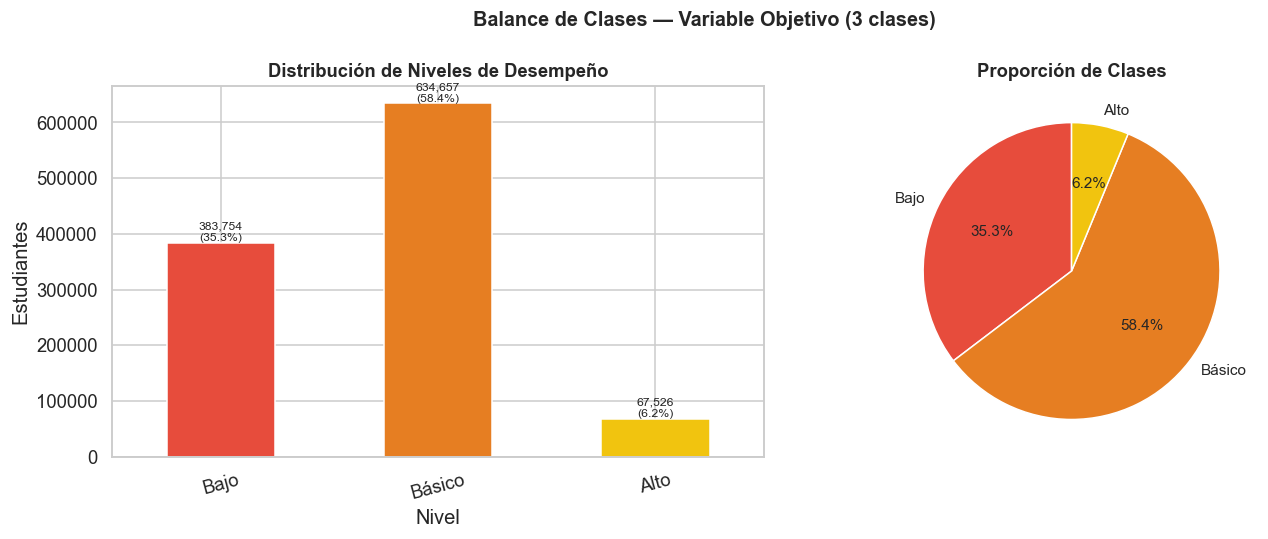

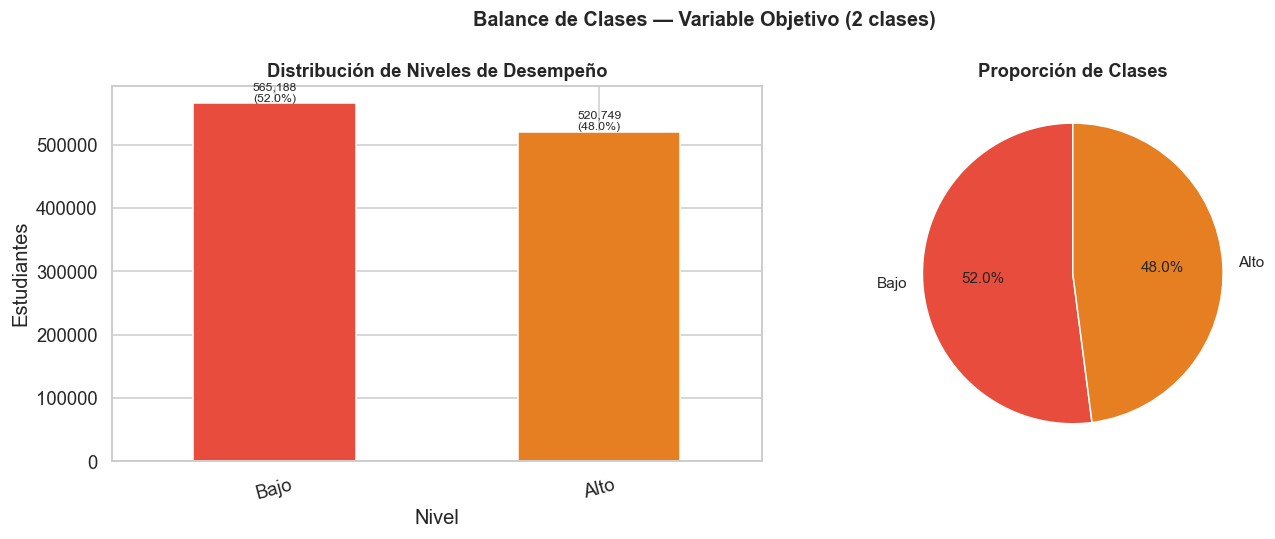

In [36]:
# ── Visualización del balance de clases ──────────────────────────────────────

COLORES = ['#E74C3C', '#E67E22', '#F1C40F']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ========== Visualización para 3 clases ==========

# Barras
dist.plot(kind='bar', ax=axes[0], color=COLORES, edgecolor='white')
axes[0].set_title('Distribución de Niveles de Desempeño',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nivel'); axes[0].set_ylabel('Estudiantes')
axes[0].tick_params(axis='x', rotation=15)
total_p = dist.sum()
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total_p * 0.003,
        f'{bar.get_height():,}\n({bar.get_height()/total_p*100:.1f}%)',
        ha='center', fontsize=8
    )

# Pie
dist.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
          colors=COLORES, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporción de Clases', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Balance de Clases — Variable Objetivo (3 clases)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_balance_clases.png', dpi=110, bbox_inches='tight')
plt.show()

# ========== Visualización para 2 clases ==========

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
dist_2.plot(kind='bar', ax=axes[0], color=COLORES[:2], edgecolor='white')
axes[0].set_title('Distribución de Niveles de Desempeño',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nivel'); axes[0].set_ylabel('Estudiantes')
axes[0].tick_params(axis='x', rotation=15)
total_p = dist_2.sum()
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total_p * 0.003,
        f'{bar.get_height():,}\n({bar.get_height()/total_p*100:.1f}%)',
        ha='center', fontsize=8
    )

# Pie
dist_2.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
            colors=COLORES[:2], startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporción de Clases', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Balance de Clases — Variable Objetivo (2 clases)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_balance_clases_2.png', dpi=110, bbox_inches='tight')
plt.show()


In [6]:
# ── Definición de columnas ────────────────────────────────────────────────────
SCORE_COLS = [c for c in ['punt_ingles','punt_matematicas','punt_c_naturales',
                            'punt_sociales_ciudadanas','punt_lectura_critica','punt_global']
              if c in df_raw.columns]

EXCLUDE_COLS = SCORE_COLS + [
    'estu_consecutivo',
    'periodo',
    'nivel_desempeno',
    'cole_cod_depto_ubicacion',

    # =========================
    # Variables adicionales
    # =========================
    'estu_tipodocumento',
    'cole_cod_mcpio_ubicacion',
    'cole_cod_departamento_unicacion',
    'cole_codigo_icfes',
    'cole_nombre_establecimiento',
    'cole_nombre_sede',
    'estu_cod_depto_presentacion',
    'estu_cod_mcpio_presentacion',
    'estu_cod_reside_mcpio',
    'estu_fechanacimiento',
    'estu_mcpio_presentacion',
    'estu_mcpio_reside',
    'estu_pais_reside',
    'desemp_ingles',
    'cole_mcpio_ubicacion',
    'cole_codigo_icfes',
    'cole_cod_dane_sede',
    'cole_cod_dane_establecimiento',
    'estu_cod_mcpio_presentacion'
]


TARGET       = 'nivel_desempeno'

# Excluir variables de alta cardinalidad (>200 categorías → problemas de memoria/encoding)
alta_card = []
for col in df.columns:
    if col not in EXCLUDE_COLS and df[col].dtype == object:
        if df[col].nunique() > 200:
            alta_card.append(col)
            EXCLUDE_COLS.append(col)

if alta_card:
    print(f'⚠️  Excluidas por alta cardinalidad (>{200} cat.): {alta_card}')

FEATURES     = [c for c in df.columns if c not in EXCLUDE_COLS]
NUM_FEATURES = df[FEATURES].select_dtypes(include='number').columns.tolist()
CAT_FEATURES = df[FEATURES].select_dtypes(include=['object','category']).columns.tolist()

print(f'\nTotal features: {len(FEATURES)}')
print(f'  → Numéricas  : {len(NUM_FEATURES)} → {NUM_FEATURES}')
print(f'  → Categóricas: {len(CAT_FEATURES)} → {CAT_FEATURES}')



Total features: 26
  → Numéricas  : 0 → []
  → Categóricas: 26 → ['cole_area_ubicacion', 'cole_calendario', 'cole_caracter', 'cole_depto_ubicacion', 'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_sede_principal', 'estu_cod_reside_depto', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_genero', 'estu_nacionalidad', 'estu_privado_libertad', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'cole_bilingue']


### 4. Limpieza Pre-Modelado: Duplicados y Registros Sin Target

In [7]:
# ── Eliminar duplicados (estu_consecutivo) ────────────────────────────────────
n_antes = len(df)
df = df[~df.duplicated(subset=['estu_consecutivo'], keep='first')].reset_index(drop=True)
df_2 = df_2[~df_2.duplicated(subset=['estu_consecutivo'], keep='first')].reset_index(drop=True)
print(f'Registros eliminados por duplicado: {n_antes - len(df):,}')

# ── Eliminar filas sin nivel_desempeno (sin punt_global válido) ────────────────
df = df.dropna(subset=['nivel_desempeno']).reset_index(drop=True)
df_2 = df_2.dropna(subset=['nivel_desempeno']).reset_index(drop=True)
print(f'Registros con target válido: {len(df):,}')

# ── Codificación numérica del target ──────────────────────────────────────────
label2idx = {l: i for i, l in enumerate(LABELS_3)}
label2idx_2 = {l: i for i, l in enumerate(LABELS_2)}
df['target'] = df['nivel_desempeno'].map(label2idx)
df_2['target'] = df_2['nivel_desempeno'].map(label2idx_2)

print('\nCodificación del target (3 clases):')
for l, i in label2idx.items():
    print(f'  {i} → {l}')

print('\nCodificación del target (2 clases):')
for l, i in label2idx_2.items():
    print(f'  {i} → {l}')



Registros eliminados por duplicado: 533,096
Registros con target válido: 552,841

Codificación del target (3 clases):
  0 → Bajo
  1 → Básico
  2 → Alto

Codificación del target (2 clases):
  0 → Bajo
  1 → Alto


### 4.1 Para dos experimentos de eliminación e imputación

In [8]:
# ── Subsets por experimento ───────────────────────────────────────────────────

# ================= Para 3 clases (Bajo, Básico, Alto) =================

X_all = df[FEATURES].copy()
y_all = df['target'].copy()

# Experimento 1: solo filas completamente limpias
mask_clean = X_all.notna().all(axis=1)
X_exp1, y_exp1 = X_all[mask_clean].reset_index(drop=True), y_all[mask_clean].reset_index(drop=True)

# Experimento 2: dataset completo (con nulos — se imputará en el pipeline)
X_exp2, y_exp2 = X_all.copy(), y_all.copy()



# ================= Para 2 clases (Bajo, Alto) =================
X_all_2 = df_2[FEATURES].copy()
y_all_2 = df_2['target'].copy()

# Experimento 1: solo filas completamente limpias
mask_clean_2 = X_all_2.notna().all(axis=1)
X_exp1_2, y_exp1_2 = X_all_2[mask_clean_2].reset_index(drop=True), y_all_2[mask_clean_2].reset_index(drop=True)

# Experimento 2: dataset completo (con nulos — se imputará en el pipeline)
X_exp2_2, y_exp2_2 = X_all_2.copy(), y_all_2.copy()

print(f'Exp 1 (Eliminación): {len(X_exp1):,} registros ({len(X_exp1)/len(X_all)*100:.1f}%)')
print(f'Exp 2 (Imputación):  {len(X_exp2):,} registros ({len(X_exp2)/len(X_all)*100:.1f}%)')



Exp 1 (Eliminación): 406,448 registros (73.5%)
Exp 2 (Imputación):  552,841 registros (100.0%)


In [9]:
# ── División Train / Test estratificada (80/20) ────────────────────────────────
RANDOM_STATE = 42

# =========== Para 3 clases ===========

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_exp1, y_exp1, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp1
)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_exp2, y_exp2, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp2
)

# =========== Para 2 clases ===========

X_tr1_2, X_te1_2, y_tr1_2, y_te1_2 = train_test_split(
    X_exp1_2, y_exp1_2, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp1_2
)
X_tr2_2, X_te2_2, y_tr2_2, y_te2_2 = train_test_split(
    X_exp2_2, y_exp2_2, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp2_2
)

print('División Train / Test (80/20, estratificada):')
print(f'  Exp 1 → Train: {len(X_tr1):,}  |  Test: {len(X_te1):,}')
print(f'  Exp 2 → Train: {len(X_tr2):,}  |  Test: {len(X_te2):,}')


División Train / Test (80/20, estratificada):
  Exp 1 → Train: 325,158  |  Test: 81,290
  Exp 2 → Train: 442,272  |  Test: 110,569


In [10]:
# Experimento 1: sin imputación (datos ya limpios)
proc_e1 = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES)
], remainder='drop')

# Experimento 2: con imputación antes de escalar/codificar
proc_e2 = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), NUM_FEATURES),

    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OneHotEncoder(handle_unknown='ignore'))
    ]), CAT_FEATURES)

], remainder='drop')

print('✅ Preprocesadores definidos.')
print('  Exp 1: StandardScaler + OneHotEncoder (sin imputación)')
print('  Exp 2: SimpleImputer(median/moda) + StandardScaler + OneHotEncoder')

✅ Preprocesadores definidos.
  Exp 1: StandardScaler + OneHotEncoder (sin imputación)
  Exp 2: SimpleImputer(median/moda) + StandardScaler + OneHotEncoder


### 4.2 Defición de la función de evaluación para el modelo

In [11]:
# ── Función de evaluación ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def evaluar(nombre, y_true, y_pred, y_prob=None, labels=None):

    """
    Calcula y muestra métricas completas de clasificación.
    Compatible con:
    - multiclase
    - binario
    - salidas one-hot/probabilidades
    """

    import numpy as np

    # ─────────────────────────────────────────────────────────────
    # Normalizar y_true
    # ─────────────────────────────────────────────────────────────
    y_true = np.array(y_true)

    # ─────────────────────────────────────────────────────────────
    # Normalizar y_pred
    # ─────────────────────────────────────────────────────────────
    y_pred = np.array(y_pred)

    # Caso: predicción tipo one-hot / multilabel
    # Ejemplo: [[0,1],[1,0],...]
    if len(y_pred.shape) > 1:

        # Si tiene más de una columna → tomar argmax
        if y_pred.shape[1] > 1:
            y_pred = np.argmax(y_pred, axis=1)

        # Si solo tiene una columna
        else:
            y_pred = y_pred.ravel()

    # ─────────────────────────────────────────────────────────────
    # Métricas principales
    # ─────────────────────────────────────────────────────────────
    acc  = accuracy_score(y_true, y_pred)

    f1m  = f1_score(
        y_true,
        y_pred,
        average='macro',
        zero_division=0
    )

    f1w  = f1_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    prec = precision_score(
        y_true,
        y_pred,
        average='macro',
        zero_division=0
    )

    rec  = recall_score(
        y_true,
        y_pred,
        average='macro',
        zero_division=0
    )

    # ─────────────────────────────────────────────────────────────
    # ROC-AUC
    # ─────────────────────────────────────────────────────────────
    auc = None

    if y_prob is not None:

        try:

            y_prob = np.array(y_prob)

            # BINARIO
            if len(np.unique(y_true)) == 2:

                # Caso predict_proba -> tomar prob clase positiva
                if len(y_prob.shape) > 1:
                    auc = roc_auc_score(y_true, y_prob[:, 1])
                else:
                    auc = roc_auc_score(y_true, y_prob)

            # MULTICLASE
            else:

                auc = roc_auc_score(
                    y_true,
                    y_prob,
                    multi_class='ovr',
                    average='macro'
                )

        except Exception as e:
            print(f'⚠️ No se pudo calcular ROC-AUC: {e}')

    # ─────────────────────────────────────────────────────────────
    # Mostrar métricas
    # ─────────────────────────────────────────────────────────────
    print(f'\n{"═"*58}')
    print(f'  {nombre}')
    print(f'{"═"*58}')

    print(f'  Accuracy            : {acc:.4f}')
    print(f'  F1-score (macro)    : {f1m:.4f}')
    print(f'  F1-score (weighted) : {f1w:.4f}')
    print(f'  Precision (macro)   : {prec:.4f}')
    print(f'  Recall (macro)      : {rec:.4f}')

    if auc is not None:
        print(f'  ROC-AUC             : {auc:.4f}')

    print()

    # ─────────────────────────────────────────────────────────────
    # Labels
    # ─────────────────────────────────────────────────────────────
    if labels is None:
        labels = [str(x) for x in sorted(np.unique(y_true))]

    print('📋 Classification Report:\n')

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=labels,
            zero_division=0
        )
    )

    # ─────────────────────────────────────────────────────────────
    # Matriz de confusión
    # ─────────────────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)

    cm_df = pd.DataFrame(
        cm,
        index=[f'Real_{l}' for l in labels],
        columns=[f'Pred_{l}' for l in labels]
    )

    print('\n📊 Matriz de Confusión (texto):\n')
    print(cm_df)

    fig, ax = plt.subplots(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.4,
        ax=ax
    )

    ax.set_title(
        f'Matriz de Confusión — {nombre}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

    plt.tight_layout()

    fn = (
        f'images/confussion_matrix/'
        f'fig_cm_{nombre.replace(" ","_").replace("(","").replace(")","").lower()}.png'
    )

    plt.savefig(fn, dpi=110, bbox_inches='tight')

    plt.show()

    # ─────────────────────────────────────────────────────────────
    # Retorno
    # ─────────────────────────────────────────────────────────────
    return {
        'modelo': nombre,
        'accuracy': acc,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'precision_macro': prec,
        'recall_macro': rec,
        'roc_auc': auc
    }


print('✅ Función evaluar() definida.')

✅ Función evaluar() definida.


### 5. Aplicación de modelo XGBoost 

Gradient boosting extremo: construye árboles secuencialmente corrigiendo errores del modelo anterior.
Incluye regularización L1/L2 y es altamente eficiente en datos tabulares.

### 5.1 Experimento 1 - Eliminación de nulos

🚀 XGBoost — Exp 1 (Eliminación)...

══════════════════════════════════════════════════════════
  XGBoost — Exp 1 (Elim.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.6783
  F1-score (macro)    : 0.5103
  F1-score (weighted) : 0.6504
  Precision (macro)   : 0.6458
  Recall (macro)      : 0.4849
  ROC-AUC             : 0.7723

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.43      0.52     26071
           1       0.69      0.87      0.77     49326
           2       0.59      0.15      0.24      5893

    accuracy                           0.68     81290
   macro avg       0.65      0.48      0.51     81290
weighted avg       0.67      0.68      0.65     81290


📊 Matriz de Confusión (texto):

        Pred_0  Pred_1  Pred_2
Real_0   11217   14838      16
Real_1    5694   43028     604
Real_2      56    4940     897


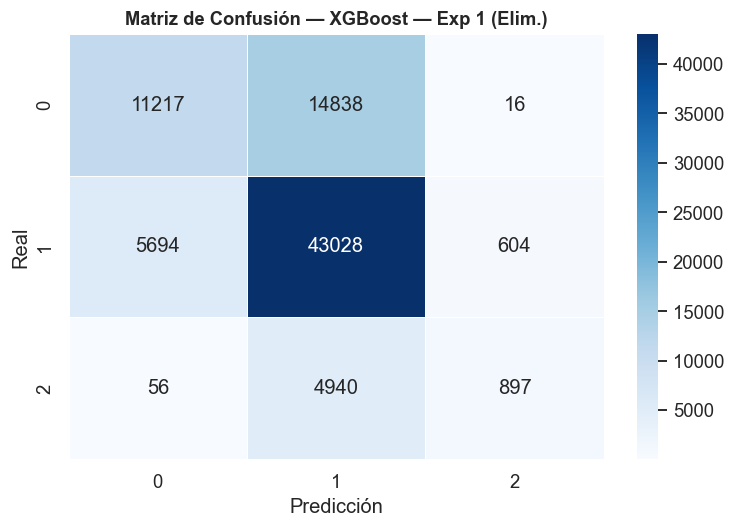

In [31]:
# ── XGBoost — Exp 1 ──────────────────────────────────────────────────────────
print('🚀 XGBoost — Exp 1 (Eliminación)...')
pipe_xgb1 = Pipeline([
    ('prep', clone(proc_e1)),
    ('clf',  XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        objective='multi:softprob', num_class=3,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1,
        verbosity=0
    ))
])
pipe_xgb1.fit(X_tr1, y_tr1)
yp_xgb1  = pipe_xgb1.predict(X_te1)
ypr_xgb1 = pipe_xgb1.predict_proba(X_te1)
met_xgb1 = evaluar('XGBoost — Exp 1 (Elim.)', y_te1, yp_xgb1, ypr_xgb1)


### 5.2 Experimento 2 - Imputación de datos

🚀 XGBoost — Exp 2 (Imputación)...

══════════════════════════════════════════════════════════
  XGBoost — Exp 2 (Imput.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.6809
  F1-score (macro)    : 0.5194
  F1-score (weighted) : 0.6591
  Precision (macro)   : 0.6515
  Recall (macro)      : 0.4962
  ROC-AUC             : 0.7865

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.50      0.58     38800
           1       0.68      0.85      0.76     64529
           2       0.59      0.14      0.22      7240

    accuracy                           0.68    110569
   macro avg       0.65      0.50      0.52    110569
weighted avg       0.68      0.68      0.66    110569


📊 Matriz de Confusión (texto):

        Pred_0  Pred_1  Pred_2
Real_0   19383   19401      16
Real_1    8947   54903     679
Real_2     101    6138    1001


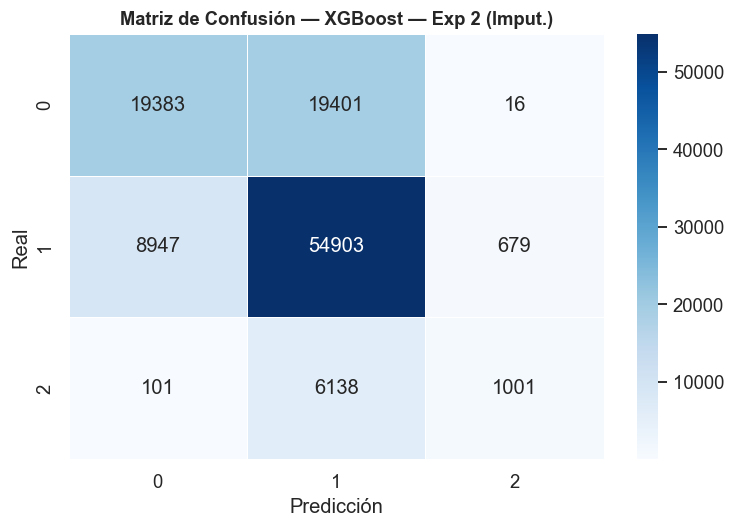

In [32]:
# ── XGBoost — Exp 2 ──────────────────────────────────────────────────────────
print('🚀 XGBoost — Exp 2 (Imputación)...')
pipe_xgb2 = Pipeline([
    ('prep', clone(proc_e2)),
    ('clf',  XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        objective='multi:softprob', num_class=3,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1,
        verbosity=0
    ))
])
pipe_xgb2.fit(X_tr2, y_tr2)
yp_xgb2  = pipe_xgb2.predict(X_te2)
ypr_xgb2 = pipe_xgb2.predict_proba(X_te2)
met_xgb2 = evaluar('XGBoost — Exp 2 (Imput.)', y_te2, yp_xgb2, ypr_xgb2)


### 5.3 Experimentos con dos categorías (Bajo/Alto)

🚀 XGBoost — Exp 1 (Binario) (Eliminación)...

══════════════════════════════════════════════════════════
  XGBoost — Exp 1 (Binario) (Elim.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.7049
  F1-score (macro)    : 0.7043
  F1-score (weighted) : 0.7046
  Precision (macro)   : 0.7049
  Recall (macro)      : 0.7042
  ROC-AUC             : 0.7793

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.68      0.69     39640
           1       0.70      0.73      0.72     41650

    accuracy                           0.70     81290
   macro avg       0.70      0.70      0.70     81290
weighted avg       0.70      0.70      0.70     81290


📊 Matriz de Confusión (texto):

        Pred_0  Pred_1
Real_0   26888   12752
Real_1   11240   30410


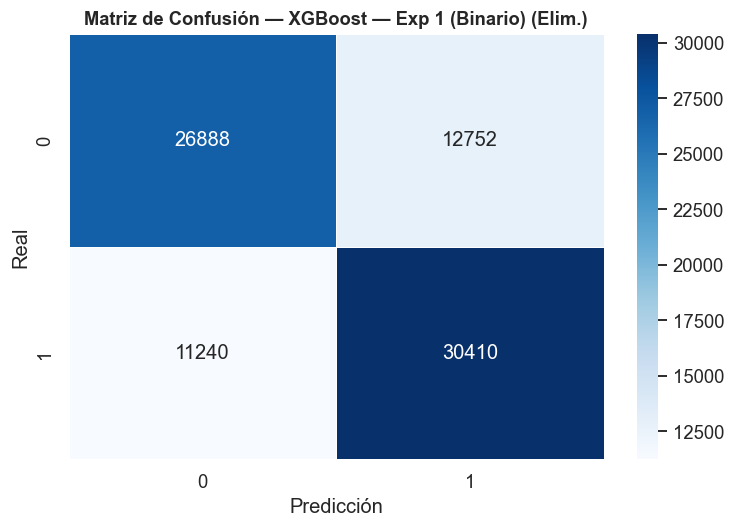

In [30]:
# ── XGBoost — Exp 1 ──────────────────────────────────────────────────────────
print('🚀 XGBoost — Exp 1 (Binario) (Eliminación)...')
pipe_xgb1 = Pipeline([
    ('prep', clone(proc_e2)),
    ('clf', XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,

        objective='binary:logistic',
        eval_metric='logloss',

        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ))
])
pipe_xgb1.fit(X_tr1_2, y_tr1_2)
yp_xgb1  = pipe_xgb1.predict(X_te1_2)
ypr_xgb1 = pipe_xgb1.predict_proba(X_te1_2)
met_xgb1 = evaluar('XGBoost — Exp 1 (Binario) (Elim.)', y_te1_2, yp_xgb1, ypr_xgb1)


🚀 XGBoost — Exp 2 (Binario) (Imputación)...

══════════════════════════════════════════════════════════
  XGBoost — Exp 2 (Binario) (Imput.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.7086
  F1-score (macro)    : 0.7082
  F1-score (weighted) : 0.7086
  Precision (macro)   : 0.7083
  Recall (macro)      : 0.7082
  ROC-AUC             : 0.7865

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.72      0.72     57144
           1       0.70      0.69      0.70     53425

    accuracy                           0.71    110569
   macro avg       0.71      0.71      0.71    110569
weighted avg       0.71      0.71      0.71    110569


📊 Matriz de Confusión (texto):

        Pred_0  Pred_1
Real_0   41253   15891
Real_1   16326   37099


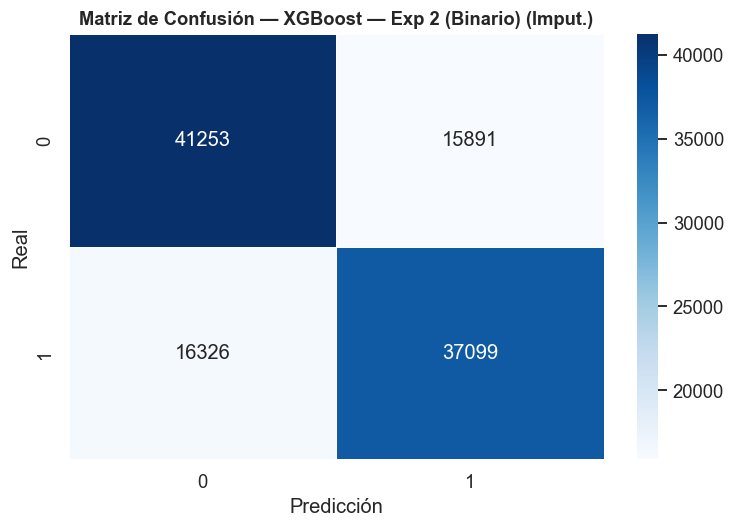

In [37]:
# ── XGBoost — Exp 2 ──────────────────────────────────────────────────────────
print('🚀 XGBoost — Exp 2 (Binario) (Imputación)...')
pipe_xgb2 = Pipeline([
    ('prep', clone(proc_e2)),
    ('clf', XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,

        objective='binary:logistic',
        eval_metric='logloss',

        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ))
])
pipe_xgb2.fit(X_tr2_2, y_tr2_2)
yp_xgb2  = pipe_xgb2.predict(X_te2_2)
ypr_xgb2 = pipe_xgb2.predict_proba(X_te2_2)
met_xgb2 = evaluar('XGBoost — Exp 2 (Binario) (Imput.)', y_te2_2, yp_xgb2, ypr_xgb2)


## Análisis - XGBoost

## Descripción

Se entrenó un modelo XGBoost para la predicción del nivel de desempeño de los estudiantes en las Pruebas Saber 11 utilizando variables sociodemográficas y características institucionales.

Al igual que con Random Forest, se evaluaron cuatro escenarios:

- Experimento 1: Clasificación multiclase (3 categorías) con eliminación de nulos.
- Experimento 2: Clasificación multiclase (3 categorías) con imputación.
- Experimento 3: Clasificación binaria (2 categorías) con eliminación de nulos.
- Experimento 4: Clasificación binaria (2 categorías) con imputación.

Configuración principal:

- n_estimators = 500
- max_depth = 6
- learning_rate = 0.1
- subsample = 0.8
- colsample_bytree = 0.8

---

## Resultados — Clasificación Multiclase

### Experimento 1: Eliminación de nulos

| Métrica | Valor |
|----------|--------|
| Accuracy | 0.6783 |
| F1 Macro | 0.5103 |
| F1 Weighted | 0.6504 |
| Precision Macro | 0.6458 |
| Recall Macro | 0.4849 |
| ROC-AUC | 0.7723 |

El modelo obtuvo una mejora importante respecto a Random Forest, alcanzando cerca de 68% de accuracy. Sin embargo, continuó mostrando dificultades para identificar correctamente la clase de alto desempeño, debido al desbalance existente entre categorías.

### Experimento 2: Imputación

| Métrica | Valor |
|----------|--------|
| Accuracy | 0.6809 |
| F1 Macro | 0.5194 |
| F1 Weighted | 0.6591 |
| Precision Macro | 0.6515 |
| Recall Macro | 0.4962 |
| ROC-AUC | 0.7865 |

La estrategia de imputación permitió una mejora adicional en todas las métricas, obteniéndose el mejor desempeño para el escenario multiclase.

---

## Resultados — Clasificación Binaria

Con el objetivo de simplificar el problema y facilitar la separación entre clases, se redefinió la variable objetivo en dos categorías:

- Bajo: puntaje ≤ 250
- Alto: puntaje > 250

### Experimento 3: Eliminación de nulos

| Métrica | Valor |
|----------|--------|
| Accuracy | 0.7049 |
| F1 Macro | 0.7043 |
| Precision Macro | 0.7049 |
| Recall Macro | 0.7042 |
| ROC-AUC | 0.7798 |

La transformación a un problema binario permitió superar la barrera del 70% en accuracy y F1-score. Además, se observó un comportamiento balanceado entre ambas clases.

### Experimento 4: Imputación

| Métrica | Valor |
|----------|--------|
| Accuracy | 0.7085 |
| F1 Macro | 0.7081 |
| Precision Macro | 0.7081 |
| Recall Macro | 0.7080 |
| ROC-AUC | 0.7865 |

Este experimento alcanzó el mejor desempeño global de todos los escenarios evaluados. El modelo logró una clasificación equilibrada entre estudiantes de bajo y alto desempeño, manteniendo simultáneamente los mayores valores de Accuracy, F1-score y ROC-AUC.

---

## Conclusiones

- XGBoost superó consistentemente a Random Forest en todos los escenarios evaluados.
- La imputación de valores faltantes generó mejoras sistemáticas respecto a la eliminación de registros.
- La clasificación binaria resultó significativamente más efectiva que la clasificación multiclase.
- El mejor modelo obtenido fue XGBoost con imputación y clasificación binaria, alcanzando aproximadamente:
  - Accuracy = 70.85%
  - F1 Macro = 70.81%
  - ROC-AUC = 78.65%

Estos resultados son consistentes con la literatura relacionada con predicción de desempeño académico basada en variables sociodemográficas, donde normalmente se reportan desempeños moderados debido a la complejidad inherente del problema.

## Se guarda el modelo ganador - XGBoost con imputación (clasificación binaria)

In [38]:
import joblib
from pathlib import Path

Path("artifacts").mkdir(exist_ok=True)

joblib.dump(
    pipe_xgb2,
    "../artifacts/xgb_icfes_binario.joblib"
)

print("✅ Modelo guardado correctamente")

✅ Modelo guardado correctamente


In [39]:
metadata = {
    "features": FEATURES,
    "labels": {
        0: "Bajo",
        1: "Alto"
    }
}

joblib.dump(
    metadata,
    "../artifacts/model_metadata.joblib"
)

['../artifacts/model_metadata.joblib']

In [40]:
import joblib

MODEL_PATH = "../artifacts/xgb_icfes_binario.joblib"

modelo = joblib.load(MODEL_PATH)

In [44]:
import pandas as pd
import time

def predict_json(payload: dict):

    start = time.perf_counter()

    df = pd.DataFrame([payload])

    prediction = modelo.predict(df)[0]

    probabilities = modelo.predict_proba(df)[0]

    processing_time_ms = (
        time.perf_counter() - start
    ) * 1000

    response = {
        "prediction": int(prediction),
        "prediction_label": (
            "Bajo"
            if prediction == 0
            else "Alto"
        ),
        "probability_bajo": round(
            float(probabilities[0]),
            4
        ),
        "probability_alto": round(
            float(probabilities[1]),
            4
        ),
        "processing_time_ms": round(
            processing_time_ms,
            2
        )
    }

    return response

### Ejemplo de predicción JSON

In [45]:
json_input = {
    "cole_area_ubicacion": "URBANO",
    "cole_calendario": "A",
    "cole_caracter": "ACADÉMICO",
    "cole_depto_ubicacion": "BOGOTÁ",
    "cole_genero": "MIXTO",
    "cole_jornada": "MAÑANA",
    "cole_naturaleza": "OFICIAL",
    "cole_sede_principal": "S",
    "estu_cod_reside_depto": "BOGOTÁ",
    "estu_depto_presentacion": "BOGOTÁ",
    "estu_depto_reside": "BOGOTÁ",
    "estu_estadoinvestigacion": "PUBLICAR",
    "estu_estudiante": "ESTUDIANTE",
    "estu_genero": "F",
    "estu_nacionalidad": "COLOMBIA",
    "estu_privado_libertad": "N",
    "fami_cuartoshogar": "Tres",
    "fami_educacionmadre": "Educación profesional completa",
    "fami_educacionpadre": "Educación profesional completa",
    "fami_estratovivienda": "Estrato 3",
    "fami_personashogar": "Cuatro",
    "fami_tieneautomovil": "Si",
    "fami_tienecomputador": "Si",
    "fami_tieneinternet": "Si",
    "fami_tienelavadora": "Si",
    "cole_bilingue": "N"
}

In [46]:
resultado = predict_json(json_input)

print(resultado)

{'prediction': 1, 'prediction_label': 'Alto', 'probability_bajo': 0.2807, 'probability_alto': 0.7193, 'processing_time_ms': 20.98}


### Para predicción sobre archivo Excel

In [52]:
import pandas as pd
import joblib
import time
from pathlib import Path


def predict_excel(
    excel_input_path: str,
    model_path: str = "modelo_xgboost_binario.joblib",
    excel_output_path: str = None
):
    """
    Genera predicciones sobre un archivo Excel y guarda
    un nuevo Excel con dos columnas adicionales:
    
    - prediction
    - prediction_label

    Parameters
    ----------
    excel_input_path : str
        Ruta del Excel de entrada.

    model_path : str
        Ruta del modelo .joblib.

    excel_output_path : str, optional
        Ruta del Excel de salida.

    Returns
    -------
    dict
    """

    start = time.perf_counter()

    # ==========================
    # Cargar modelo
    # ==========================
    modelo = joblib.load(model_path)

    # ==========================
    # Leer Excel
    # ==========================
    df = pd.read_excel(excel_input_path)

    # ==========================
    # Predicciones
    # ==========================
    predicciones = modelo.predict(df)

    # ==========================
    # Agregar columnas
    # ==========================
    df["prediction"] = predicciones.astype(int)

    df["prediction_label"] = (
        df["prediction"]
        .map({
            0: "Bajo",
            1: "Alto"
        })
    )

    # ==========================
    # Definir salida
    # ==========================
    if excel_output_path is None:

        input_file = Path(excel_input_path)

        excel_output_path = (
            input_file.parent /
            f"{input_file.stem}_predicciones.xlsx"
        )

    # ==========================
    # Guardar Excel
    # ==========================
    df.to_excel(
        excel_output_path,
        index=False
    )

    processing_time_ms = (
        time.perf_counter() - start
    ) * 1000

    return {
        "rows_processed": len(df),
        "output_file": str(excel_output_path),
        "processing_time_ms": round(
            processing_time_ms,
            2
        )
    }

### Ejemplo de predicción Excel

In [53]:
resultado = predict_excel(
    excel_input_path="../excel_files/output_multiple.xlsx",
    model_path="../artifacts/xgb_icfes_binario.joblib"
)

print(resultado)

{'rows_processed': 5, 'output_file': '..\\excel_files\\output_multiple_predicciones.xlsx', 'processing_time_ms': 100.79}


In [55]:
joblib.load("../artifacts/model_metadata.joblib")

{'features': ['cole_area_ubicacion',
  'cole_calendario',
  'cole_caracter',
  'cole_depto_ubicacion',
  'cole_genero',
  'cole_jornada',
  'cole_naturaleza',
  'cole_sede_principal',
  'estu_cod_reside_depto',
  'estu_depto_presentacion',
  'estu_depto_reside',
  'estu_estadoinvestigacion',
  'estu_estudiante',
  'estu_genero',
  'estu_nacionalidad',
  'estu_privado_libertad',
  'fami_cuartoshogar',
  'fami_educacionmadre',
  'fami_educacionpadre',
  'fami_estratovivienda',
  'fami_personashogar',
  'fami_tieneautomovil',
  'fami_tienecomputador',
  'fami_tieneinternet',
  'fami_tienelavadora',
  'cole_bilingue'],
 'labels': {0: 'Bajo', 1: 'Alto'}}

In [56]:
feature_values = {}

for col in FEATURES:
    feature_values[col] = (
        df_2[col]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

metadata = {
    "features": FEATURES,
    "labels": {
        0: "Bajo",
        1: "Alto"
    },
    "feature_values": feature_values
}

joblib.dump(
    metadata,
    "../artifacts/model_metadata.joblib"
)

['../artifacts/model_metadata.joblib']

In [57]:
joblib.load("../artifacts/model_metadata.joblib")

{'features': ['cole_area_ubicacion',
  'cole_calendario',
  'cole_caracter',
  'cole_depto_ubicacion',
  'cole_genero',
  'cole_jornada',
  'cole_naturaleza',
  'cole_sede_principal',
  'estu_cod_reside_depto',
  'estu_depto_presentacion',
  'estu_depto_reside',
  'estu_estadoinvestigacion',
  'estu_estudiante',
  'estu_genero',
  'estu_nacionalidad',
  'estu_privado_libertad',
  'fami_cuartoshogar',
  'fami_educacionmadre',
  'fami_educacionpadre',
  'fami_estratovivienda',
  'fami_personashogar',
  'fami_tieneautomovil',
  'fami_tienecomputador',
  'fami_tieneinternet',
  'fami_tienelavadora',
  'cole_bilingue'],
 'labels': {0: 'Bajo', 1: 'Alto'},
 'feature_values': {'cole_area_ubicacion': ['URBANO', 'RURAL'],
  'cole_calendario': ['B', 'A', 'OTRO'],
  'cole_caracter': ['ACADÉMICO', 'TÉCNICO/ACADÉMICO', 'TÉCNICO', 'NO APLICA'],
  'cole_depto_ubicacion': ['VALLE',
   'BOGOTÁ',
   'ANTIOQUIA',
   'CESAR',
   'CAUCA',
   'SANTANDER',
   'QUINDIO',
   'CUNDINAMARCA',
   'NARIÑO',
   'ATL